In [97]:
import os
import yaml
import pandas as pd

In [98]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [99]:
with open ('../configs/config.yaml', 'r') as stream:
    try:
        cfg = yaml.safe_load(stream)
        print(cfg)
    except yaml.YAMLError as exc:
        print(exc) 

{'random_seed': 42, 'data': {'raw_path': 'data/raw/womens_clothing_ecommerce_reviews_balanced.csv', 'processed_dir': 'data/processed', 'text_column': 'review_body', 'sentiment_label': 'SENTIMENT', 'rating_label': 'RATING', 'recommend_label': 'RECOMMEND', 'test': 'HRRRY'}, 'preprocessing': {'lowercase': True, 'strip_punctuation': True, 'remove_numbers': False, 'handle_negations': True, 'lemmatize': True, 'stopwords': 'english'}, 'vectorization': {'type': 'tfidf', 'ngram_range': [1, 2], 'max_features': 20000, 'min_df': 2}, 'evaluation': {'cv_folds': 5}}


In [100]:
df = pd.read_csv('../' + cfg['data']['raw_path'])

In [101]:
df[df['review_body'].duplicated(keep = False) == True]

,sentiment,review_body,product_category
259,-1,I purchased this and another eva franco dress ...,Dresses
2071,-1,I purchased this and another eva franco dress ...,Dresses


The label match for the duplicated rows, so its a safe duplicate

### Class balance

In [102]:
df['sentiment'].value_counts()

sentiment
-1    2370
 0    2370
 1    2370
Name: count, dtype: int64

In [103]:
df['sentiment'].value_counts()/df['sentiment'].value_counts().sum()

sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: count, dtype: float64

<Axes: xlabel='sentiment', ylabel='count'>

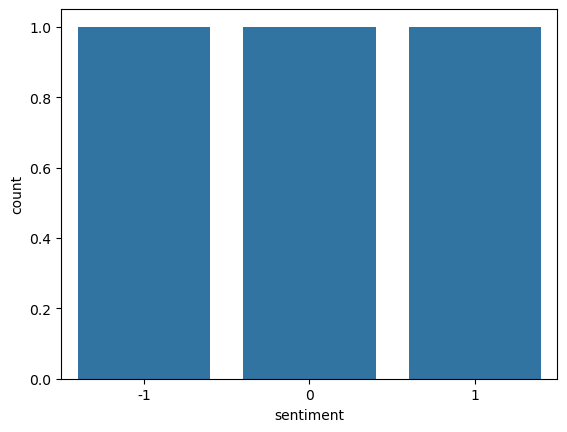

In [104]:
import seaborn as sns
sns.countplot(df['sentiment'].value_counts())

it sound balanced

In [105]:
# creating review length 
df['review_length'] = df['review_body'].apply(lambda x : len(x.split()))

In [106]:
df['review_body'].iloc[348].split()

['So', 'much', 'right', 'but', 'then....too', 'short.']

In [107]:
df[df['review_length'] < 7]

,sentiment,review_body,product_category,review_length
348,-1,So much right but then....too short.,Blouses,6
1086,-1,Super itchy! had to return.,Legwear,5
2218,-1,Totally see through.,Lounge,3
2246,-1,Unforgiving to even your smallest imperfections.,Dresses,6
2430,0,Very pretty romantic,Sleep,3
2697,0,The sweater is cute but scratchy.,Sweaters,6
2971,0,Cute but too thick and rough,Sweaters,6
3794,0,Love the feel and comfort,Knits,5
4023,0,I never write reviews,Dresses,4
4720,0,Low waisted weird liner.,Pants,4


In [108]:
df['review_length'].describe()

count    7110.000000
mean       61.018847
std        27.680663
min         2.000000
25%        38.000000
50%        60.000000
75%        88.000000
max       115.000000
Name: review_length, dtype: float64

In [109]:
df[df['review_length'] < 3].sum()

sentiment                     1
review_body         Comfy cozy!
product_category          Knits
review_length                 2
dtype: object

### Preprocessing

In [110]:
# import nltk
# nltk.download("stopwords")
# nltk.download("wordnet")
# nltk.download("omw-1.4")

In [111]:
import string

In [112]:
import nltk
nltk.download("averaged_perceptron_tagger")
nltk.download("averaged_perceptron_tagger_eng")
nltk.download("stopwords")

[nltk_data] Error loading averaged_perceptron_tagger: <urlopen error
[nltk_data]     [Errno 8] nodename nor servname provided, or not
[nltk_data]     known>
[nltk_data] Error loading averaged_perceptron_tagger_eng: <urlopen
[nltk_data]     error [Errno 8] nodename nor servname provided, or not
[nltk_data]     known>
[nltk_data] Error loading stopwords: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

In [113]:
import sys, os
sys.path.append(os.path.abspath(".."))  # go one level up from notebooks/
from src.features.text_prep import preprocess_text


In [114]:
df['processed_text'] = df['review_body'].apply(lambda x : preprocess_text(x, cfg))

In [115]:
from nltk import pos_tag, word_tokenize
from nltk.corpus import wordnet
from nltk.stem import WordNetLemmatizer

nltk.download('punkt')
nltk.download('averaged_percpetron_tagger')
nltk.download("wordnet")
nltk.download('punkt_tab')

[nltk_data] Error loading punkt: <urlopen error [Errno 8] nodename nor
[nltk_data]     servname provided, or not known>
[nltk_data] Error loading averaged_percpetron_tagger: <urlopen error
[nltk_data]     [Errno 8] nodename nor servname provided, or not
[nltk_data]     known>
[nltk_data] Error loading wordnet: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>
[nltk_data] Error loading punkt_tab: <urlopen error [Errno 8] nodename
[nltk_data]     nor servname provided, or not known>


False

In [116]:
from src.features import vectorize

v_test = vectorize.build_vectorizer(cfg)

print(type(v_test).__name__)

Vectorizer type from config is:  'tfidf'
TfidfVectorizer


In [117]:
seed = cfg['random_seed']

In [118]:
df.head(3)

,sentiment,review_body,product_category,review_length,processed_text
0,-1,This suit did nothing for me. the top has zero...,Swim,83,suit nothing top zero support would work young...
1,-1,Like other reviewers i saw this dress on the ...,Dresses,98,like reviewer saw dress cover catalog know wel...
2,-1,I wish i had read the reviews before purchasin...,Knits,74,wish read review purchase online love top look...


In [119]:
# create index column in the dataframe and name it doc_id
df = df.reset_index().rename(columns = {'index' : 'doc_id'})

In [120]:
df.head()

,doc_id,sentiment,review_body,product_category,review_length,processed_text
0,0,-1,This suit did nothing for me. the top has zero...,Swim,83,suit nothing top zero support would work young...
1,1,-1,Like other reviewers i saw this dress on the ...,Dresses,98,like reviewer saw dress cover catalog know wel...
2,2,-1,I wish i had read the reviews before purchasin...,Knits,74,wish read review purchase online love top look...
3,3,-1,I ordered these pants in my usual size (xl) an...,Legwear,54,ordered pant usual size xl shock received wais...
4,4,-1,I noticed this top on one of the sales associa...,Knits,56,notice top one sale associate look great shes ...


In [121]:
from sklearn.model_selection import train_test_split

# using stratified split to preserve class ratios 

trainval_df , test_df = train_test_split(df, test_size= 0.10, stratify= df['sentiment'], random_state=seed)

In [122]:
val_ratio_of_trainval = 0.10 / 0.90 # ~ 0.111111

train_df, val_df = train_test_split(trainval_df, test_size= val_ratio_of_trainval,
                                    stratify= trainval_df['sentiment'],
                                    random_state= seed)

In [123]:
# sizes add up?
assert len(train_df) + len(val_df) + len(test_df) == len(df)

# no overlaps?
assert set(train_df['doc_id']).isdisjoint(val_df['doc_id'])
assert set(train_df['doc_id']).isdisjoint(test_df['doc_id'])
assert set(val_df['doc_id']).isdisjoint(test_df['doc_id'])

# class balance preserved? (roughly equal proportions)
def props(s): return s.value_counts(normalize=True).sort_index()

print("ALL:\n", props(df['sentiment']))
print("TRAIN:\n", props(train_df['sentiment']))
print("VAL:\n", props(val_df['sentiment']))
print("TEST:\n", props(test_df['sentiment']))

ALL:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64
TRAIN:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64
VAL:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64
TEST:
 sentiment
-1    0.333333
 0    0.333333
 1    0.333333
Name: proportion, dtype: float64


In [124]:
train_df.head()

,doc_id,sentiment,review_body,product_category,review_length,processed_text
4634,4634,0,"I'm 5'6"" and it hits me at mid-thigh. the top ...",Dresses,47,im 56 hit midthigh top blackcamel version shee...
1792,1792,-1,This sweater is the perfect sweater except for...,Sweaters,68,sweater perfect sweater except one thingit she...
3972,3972,0,This is a very fetching little dress but the d...,Dresses,85,fetch little dress detail fit described review...
1381,1381,-1,This skirt is gianormous! i usually take an xl...,Skirts,89,skirt gianormous usually take xl l order waist...
4278,4278,0,"I'm 5'6"" 34b/32c apprx 125# & lift weights ...",Dresses,94,im 56 34b32c apprx 125 lift weight biggermuscu...


In [125]:
# keep only what we need : 
os.makedirs('../data/processed', exist_ok=True)

cols = ['doc_id', 'processed_text', 'sentiment']

train_df[cols].to_csv('../data/processed/train.csv', index = False)
val_df[cols].to_csv('../data/processed/val.csv', index = False)
test_df[cols].to_csv('../data/processed/test.csv', index = False)

In [126]:
from src.data.loader import load_split

In [127]:
train_texts , y_train, id_train = load_split('train', cfg)

In [128]:
val_texts, y_val, id_val = load_split('val', cfg)
test_texts, y_test, id_test = load_split('test', cfg)

### Build the Vectorzier and fit & Tranform on training data - Transform on testing and evaluation data

In [129]:
from src.features.vectorize import build_vectorizer

In [130]:
vec = build_vectorizer(cfg = cfg)

Vectorizer type from config is:  'tfidf'


In [131]:
cfg['vectorization']['type']

'tfidf'

In [132]:
# fitting on training data 
vec.fit(train_texts)

,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None
,analyzer,'word'
,stop_words,None
,token_pattern,'(?u)\\b\\w\\w+\\b'
,ngram_range,"(1, ...)"


In [133]:
X_tr = vec.transform(train_texts)
X_test = vec.transform(test_texts)
X_vaal = vec.transform(val_texts)

In [134]:
X_tr.toarray().shape

(5688, 20000)

In [135]:
X_tr.getnnz(axis = 1)

array([35, 38, 50, ..., 25, 40, 54], shape=(5688,), dtype=int32)

In [136]:
vec.vocabulary_

{'im': np.int64(8139),
 '56': np.int64(486),
 'hit': np.int64(7721),
 'midthigh': np.int64(10654),
 'top': np.int64(17108),
 'version': np.int64(18158),
 'sheer': np.int64(13692),
 'enough': np.int64(5041),
 'need': np.int64(10900),
 'cami': np.int64(2275),
 'waist': np.int64(18220),
 'quite': np.int64(12608),
 'high': np.int64(7623),
 'not_flattering': np.int64(11153),
 'empire': np.int64(5005),
 'make': np.int64(10329),
 'look': np.int64(9899),
 'bit': np.int64(1817),
 'dont': np.int64(4356),
 'want': np.int64(18358),
 'deal': np.int64(3772),
 'wear': np.int64(18655),
 'im 56': np.int64(8164),
 '56 hit': np.int64(499),
 'hit midthigh': np.int64(7736),
 'sheer enough': np.int64(13698),
 'need cami': np.int64(10906),
 'waist quite': np.int64(18295),
 'empire waist': np.int64(5006),
 'waist make': np.int64(18273),
 'make look': np.int64(10371),
 'look bit': np.int64(9916),
 'dont want': np.int64(4404),
 'want deal': np.int64(18366),
 'wear cami': np.int64(18694),
 'sweater': np.int64(16

In [137]:
vec.vocabulary_.keys()

dict_keys(['im', '56', 'hit', 'midthigh', 'top', 'version', 'sheer', 'enough', 'need', 'cami', 'waist', 'quite', 'high', 'not_flattering', 'empire', 'make', 'look', 'bit', 'dont', 'want', 'deal', 'wear', 'im 56', '56 hit', 'hit midthigh', 'sheer enough', 'need cami', 'waist quite', 'empire waist', 'waist make', 'make look', 'look bit', 'dont want', 'want deal', 'wear cami', 'sweater', 'perfect', 'except', 'one', 'shed', 'everywhere', 'simply', 'pick', 'shake', 'hand', '40', 'large', 'piece', 'lint', 'go', 'like', 'dark', 'jean', 'purchase', 'walk', 'store', 'salesperson', 'use', 'much', 'sweater perfect', 'perfect sweater', 'sweater except', 'except one', 'shed everywhere', 'one hand', 'large piece', 'like dark', 'dark jean', 'jean dont', 'dont purchase', 'walk store', 'shed much', 'little', 'dress', 'detail', 'fit', 'described', 'reviewer', 'slightly', '34d', '55', '140', 'lbs', 'perfectly', 'odd', 'gap', 'button', 'placket', 'fabric', 'nice', 'not_exactly', 'expect', 'must', 'flat', 

In [138]:
vec.vocabulary_.items()

dict_items([('im', np.int64(8139)), ('56', np.int64(486)), ('hit', np.int64(7721)), ('midthigh', np.int64(10654)), ('top', np.int64(17108)), ('version', np.int64(18158)), ('sheer', np.int64(13692)), ('enough', np.int64(5041)), ('need', np.int64(10900)), ('cami', np.int64(2275)), ('waist', np.int64(18220)), ('quite', np.int64(12608)), ('high', np.int64(7623)), ('not_flattering', np.int64(11153)), ('empire', np.int64(5005)), ('make', np.int64(10329)), ('look', np.int64(9899)), ('bit', np.int64(1817)), ('dont', np.int64(4356)), ('want', np.int64(18358)), ('deal', np.int64(3772)), ('wear', np.int64(18655)), ('im 56', np.int64(8164)), ('56 hit', np.int64(499)), ('hit midthigh', np.int64(7736)), ('sheer enough', np.int64(13698)), ('need cami', np.int64(10906)), ('waist quite', np.int64(18295)), ('empire waist', np.int64(5006)), ('waist make', np.int64(18273)), ('make look', np.int64(10371)), ('look bit', np.int64(9916)), ('dont want', np.int64(4404)), ('want deal', np.int64(18366)), ('wear c

In [139]:
from src.diagnostics.sanity import summzarize_split, vectorizer_summary

In [140]:
summzarize_split(X_tr, 'train')

The number of Documents in train split is 5688
The number of Features in train split is 20000
Number of all-zero features in train split is 0
The Density of the train split is 0.002001
Number of non-zero entries per row in train is [35 38 50 ... 25 40 54]
---------------------------------
The Total Number of non-zero entries in train is 227664
Empty rows (docs with no surviving features) is 0
Percentage of empties is 0.0000%
Mean nnz per doc: 40.0253
Median nnz per doc: 40.0000
95th percentile nnz per doc: 67.00


In [141]:
import inspect, importlib
import src.diagnostics.sanity as vectorizer_summary

In [142]:
vec.get_feature_names_out()

array(['00', '00 petite', '00 regular', ..., 'zipper would',
       'zipper wouldnt', 'zoom'], shape=(20000,), dtype=object)

In [143]:
summzarize_split(X_tr, 'train')

The number of Documents in train split is 5688
The number of Features in train split is 20000
Number of all-zero features in train split is 0
The Density of the train split is 0.002001
Number of non-zero entries per row in train is [35 38 50 ... 25 40 54]
---------------------------------
The Total Number of non-zero entries in train is 227664
Empty rows (docs with no surviving features) is 0
Percentage of empties is 0.0000%
Mean nnz per doc: 40.0253
Median nnz per doc: 40.0000
95th percentile nnz per doc: 67.00


In [144]:
summzarize_split(X_test, 'test')

The number of Documents in test split is 711
The number of Features in test split is 20000
Number of all-zero features in test split is 13153
The Density of the test split is 0.001882
Number of non-zero entries per row in test is [67 59 13 62 40 52 61 40 43 37 52 19 18 51 48 38 21 62 21 29 45 56 22 32
 23 51 32 68 19 31 32 25 24 58 61 13 19 62 25 36 33 47 26 43 17 20 45 12
 62 45 36 49 37 50 21 59 29 57 18 17 34 51 58 21 49 29 27 23 35 33 50 38
 25 57 44  6 51 59 38  7 40 12 27 24 23 47 46 31 23 52 26 35 49 30 38 20
 52 52 37 25 12 62 51 52 58 53 36 53 47 10 43 44 42 46 28 36 24 19 58 33
 48 43 49 52 26 63 19 45 13 37 30 67 16 43 46 28 51 19 23 52 19 69 24 60
 29 22 55 23 43 58 62 32 39 63 40 17 49 41 55 59 22 21 31 51 37 56 53 49
 32 28 17 55 50 46 34 61 37 61 44 56 33 42 47 53 46 39 38 69 50 35 54 31
 51 38 43 40 13 53 48 47 42 58 50 17 54 28 42 18 23  1 39 15 20 47 29 50
 56 38 46 19 33  8 31 21 44 29 41 22 17 55 52 65 55 42 48 11 46 57 65 47
 32 52 27 47 51 40 39 54 25 20 54 28  7 

In [145]:
summzarize_split(X_vaal, 'val')

The number of Documents in val split is 711
The number of Features in val split is 20000
Number of all-zero features in val split is 13303
The Density of the val split is 0.001859
Number of non-zero entries per row in val is [32 28 10 68 33 20 11 33 44 14 34 55 38 44 19 68  8 35 49 14 42 22 20 22
 17 24 18 59 50 63 37 20  8 36 31 29 53 22 30 30 39 47 23 24 36 33 20 32
 30 28 22 49 32 11 51 36 36 37 31 32 57 27 57 12 42 37 60 65 27 36 31 35
 62 25 24 29 25 42 53 22 47 28 55  6 61 35 22 38 53 34 21 51 23 54 36 55
 28 11 45 47 32 12 49 17 32 39 52 29 20 49 64 39 32 62 44 32 34 47 33 62
 24 70 40 22 26 19 40 32 16 67 30 26 58 17 53 14 69 32 44 46 66 60 27 17
 52 31 23 21 21 44 55 63 59 43 15 18 65 30 42 10 55  7 56 42 40 31 43 36
 62 53 17 14 55 40 35 21 36 53 27 27 51 50 50 49 46 51 22 26 51 15 49 56
 39 65 49 33 49 65 22 49 42 53 36 34  8 36 37 35 44 37 23 12 56 26 44 44
 53 52  9 54 30 47 29 39 66 37 32 53 18 57 60 23 45 11 20 48 22 41 25 21
 27 47 54 33 28 13 43 29 61 15 22 26 14 28 26

In [146]:
from src.diagnostics.sanity import vectorizer_summary
vectorizer_summary(vec)


   ngram_range:  ======> (1, 2)

        min_df:  ======> 2

        max_df:  ======> 1.0

  max_features:  ======> 20000

     lowercase:  ======> True

    stop_words:  ======> None

       use_idf:  ======> True

  sublinear_tf:  ======> False

          norm:  ======> l2

Vocabulary size:  ======>  20,000

Sample of the Features: 
00, 00 petite, 00 regular, 00 size, 000, 00p, 00p 0p, 02, 0p, 0p 00p ,,, zipper split, zipper try, zipper would, zipper wouldnt, zoom

IDF range: min = 2.0330, Median = 8.2600, Max =  8.5477
#######################################
The Top 20 terms by IDF (Rarest) are :
cheap poly, size vneck, size thing, get 20, genius, generously size, size true, generously cut, size twice, absolutely horrible, generous fit, size unflattering, generally find, generally dont, gear, size ten, gauge, gaudy, gathering, gather waist
#######################################
The Top 20 terms by LOW IDF (Common) are :
look, fit, love, like, size, dress, wear, top, color, would, 

In [147]:
'not_fit' in vec.vocabulary_.keys()

True

In [148]:
len(vec.vocabulary_)

20000

Saving the fitted Vector (reporoducability)

In [149]:
from src.features.persist import load_vectorizer

In [150]:
# persist_vectorizer(vec, '../artifacts')

In [151]:
from sklearn.metrics import f1_score

f1_score([1, 0, 0 , 1, 1, -1, 1, 0, 1, 1, 0, -1, -1], [0, 1, 1, -1, 1, 0, 1, -1, 1, 0, 0, 1, -1], average=None, labels = [1, 0, -1]).tolist()

[0.5, 0.25, 0.3333333333333333]

In [152]:
from src.models.baselines import train_dummy, train_log, train_nb, train_svc, run_all_baselines
from src.eval.metrics import accuracy, accuracy_score, confusion, evaluate_model

In [153]:
train_dummy(X_tr, y_train, X_vaal, y_val)

(DummyClassifier(strategy='most_frequent'),
 {'model': 'Dummy_Classifier',
  'acc_val': 0.3333333333333333,
  'macro_f1_val': 0.16666666666666666,
  'acc_train': 0.3333333333333333,
  'macro_f1_train': 0.16666666666666666,
  'confusion_val': array([[  0,   0, 237],
         [  0,   0, 237],
         [  0,   0, 237]]),
  'per_class_f1_val': {'Positive (1)': 0.0,
   'Neutral (0)': 0.0,
   'Negative (-1)': 0.5}})

In [154]:
train_log(X_tr, y_train, X_vaal, y_val)

(LogisticRegression(max_iter=10000, multi_class='ovr', n_jobs=-1,
                    solver='liblinear'),
 {'model': 'Logistic_Regression',
  'acc_val': 0.6511954992967651,
  'macro_f1_val': 0.6421965128368433,
  'acc_train': 0.8834388185654009,
  'macro_f1_train': 0.8828368114932337,
  'confusion_val': array([[204,  23,  10],
         [ 52, 108,  77],
         [ 26,  60, 151]]),
  'per_class_f1_val': {'Positive (1)': 0.7861271676300579,
   'Neutral (0)': 0.5046728971962616,
   'Negative (-1)': 0.6357894736842106}})

In [155]:
train_nb(X_tr, y_train, X_vaal, y_val)

(MultinomialNB(),
 {'model': 'Naive-Bayes Classifier',
  'acc_val': 0.6413502109704642,
  'macro_f1_val': 0.6400169906677585,
  'acc_train': 0.914732770745429,
  'macro_f1_train': 0.9147945501889291,
  'confusion_val': array([[194,  34,   9],
         [ 41, 120,  76],
         [ 12,  83, 142]]),
  'per_class_f1_val': {'Positive (1)': 0.8016528925619835,
   'Neutral (0)': 0.5063291139240507,
   'Negative (-1)': 0.6120689655172413}})

In [156]:
train_svc(X_tr, y_train, X_vaal, y_val)

(LinearSVC(),
 {'model': 'Support Vector Classifier',
  'acc_val': 0.6244725738396625,
  'macro_f1_val': 0.6169557226853256,
  'acc_train': 0.9989451476793249,
  'macro_f1_train': 0.9989448687668352,
  'confusion_val': array([[200,  29,   8],
         [ 54, 101,  82],
         [ 17,  77, 143]]),
  'per_class_f1_val': {'Positive (1)': 0.7874015748031497,
   'Neutral (0)': 0.45495495495495497,
   'Negative (-1)': 0.6085106382978723}})

In [157]:
run_all_baselines(X_tr, y_train, X_vaal, y_val)

({'Dummy': DummyClassifier(strategy='most_frequent'),
  'Naive_Bayes': MultinomialNB(),
  'Logistic_regression': LogisticRegression(max_iter=10000, multi_class='ovr', n_jobs=-1,
                     solver='liblinear'),
  'Support_Vector_Classification': LinearSVC()},
 [{'model': 'Dummy_Classifier',
   'acc_val': 0.3333333333333333,
   'macro_f1_val': 0.16666666666666666,
   'acc_train': 0.3333333333333333,
   'macro_f1_train': 0.16666666666666666,
   'confusion_val': array([[  0,   0, 237],
          [  0,   0, 237],
          [  0,   0, 237]]),
   'per_class_f1_val': {'Positive (1)': 0.0,
    'Neutral (0)': 0.0,
    'Negative (-1)': 0.5}},
  {'model': 'Naive-Bayes Classifier',
   'acc_val': 0.6413502109704642,
   'macro_f1_val': 0.6400169906677585,
   'acc_train': 0.914732770745429,
   'macro_f1_train': 0.9147945501889291,
   'confusion_val': array([[194,  34,   9],
          [ 41, 120,  76],
          [ 12,  83, 142]]),
   'per_class_f1_val': {'Positive (1)': 0.8016528925619835,
   

In [158]:
from src.models.persist import save_model, load_model
from src.features.persist import load_vectorizer

In [159]:
m, metrics = train_log(X_tr, y_train, X_vaal, y_val)

In [160]:
save_model(m, '../artifacts/', 'losgitic_reg_basline')

The model Has been Saved Sucessfuly


'../artifacts/losgitic_reg_basline.pkl'

In [161]:
model = load_model('../artifacts', 'losgitic_reg_basline')
vectorizer = load_vectorizer('../artifacts', 'tfidf_vectorizer')

In [162]:
X_test = vectorizer.transform(test_texts)

In [163]:
y_test_pred = model.predict(X_test)

In [164]:
accuracy(y_test, y_test_pred)

0.6357243319268636

In [165]:
from src.eval.metrics import accuracy, macro_f1, per_class_f1, confusion

In [166]:
macro_f1(y_test, y_test_pred)

0.6317094739732659

In [167]:
per_class_f1(y_test, y_test_pred)

{'Positive (1)': 0.7710843373493976,
 'Neutral (0)': 0.5043859649122807,
 'Negative (-1)': 0.6196581196581197}

In [168]:
confusion(y_test, y_test_pred)

array([[192,  36,   9],
       [ 45, 115,  77],
       [ 24,  68, 145]])

	•	Results are very close to your validation scores (val macro-F1 ~0.642), which is what we want. No sign of train→val→test drift or leakage.

    
	•	The Neutral class is still the hardest (F1 ~0.50). You can see many neutrals being pushed to ±1 in the confusion matrix (45 to +1, 77 to −1).

In [169]:
from src.models.train_pipeline import run_gridsearch

In [170]:
train_text, y_train, id_train = load_split('train', cfg = cfg)

In [171]:
print(len(train_text))
print(len(y_train))
print(len(id_train))

5688
5688
5688


In [172]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [173]:
best_pipe = run_gridsearch(train_text, y_train, random_state=cfg['random_seed'])

Fitting 5 folds for each of 120 candidates, totalling 600 fits
[CV] END clf=LogisticRegression(max_iter=2000, multi_class='multinomial'), clf__C=0.5, clf__class_weight=None, tfidf__max_df=0.9, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=2000, multi_class='multinomial'), clf__C=0.5, clf__class_weight=None, tfidf__max_df=0.9, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=2000, multi_class='multinomial'), clf__C=0.5, clf__class_weight=None, tfidf__max_df=0.9, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=2000, multi_class='multinomial'), clf__C=0.5, clf__class_weight=None, tfidf__max_df=0.9, tfidf__min_df=1, tfidf__ngram_range=(1, 1), tfidf__sublinear_tf=True; total time=   0.1s
[CV] END clf=LogisticRegression(max_iter=2000, multi_class='m

	•	This means the average F1-score across all three classes (Positive, Neutral, Negative) is ≈ 0.66.
	•	That’s an improvement from the earlier baselines (~0.64 on validation).
	•	It indicates the model is now slightly better balanced across classes after hyper-parameter tuning.

In [174]:
text_val, y_val, id_val = load_split('val', cfg = cfg)

In [175]:
y_val_pred = best_pipe.predict(text_val)

In [176]:
from src.eval.metrics import eval_model

In [177]:
eval_model(y_val, y_val_pred, 'best_pipe')

{'model': 'best_pipe',
 'acc_val': 0.6483825597749648,
 'macro_f1': 0.642150547699553,
 'confusion': array([[199,  30,   8],
        [ 53, 113,  71],
        [ 22,  66, 149]]),
 'per_class_f1_val': {'Positive (1)': 0.7788649706457925,
  'Neutral (0)': 0.5067264573991032,
  'Negative (-1)': 0.6408602150537634}}

In [178]:
import numpy as np

In [179]:
text_X_traval = train_text + text_val
y_traval = np.concat([y_train, y_val])

In [180]:
best_pipe.fit(text_X_traval, y_traval)

,steps,"[('tfidf', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [181]:
y_test_pred = best_pipe.predict(test_texts)

In [182]:
eval_model(y_test, y_test_pred, 'best_pipe')

{'model': 'best_pipe',
 'acc_val': 0.6469760900140648,
 'macro_f1': 0.6454540359141067,
 'confusion': array([[189,  39,   9],
        [ 36, 125,  76],
        [ 23,  68, 146]]),
 'per_class_f1_val': {'Positive (1)': 0.7793814432989691,
  'Neutral (0)': 0.5330490405117271,
  'Negative (-1)': 0.6239316239316239}}

In [183]:
save_model(best_pipe, '../artifacts', 'final_sentiment_pipe')

The model Has been Saved Sucessfuly


'../artifacts/final_sentiment_pipe.pkl'

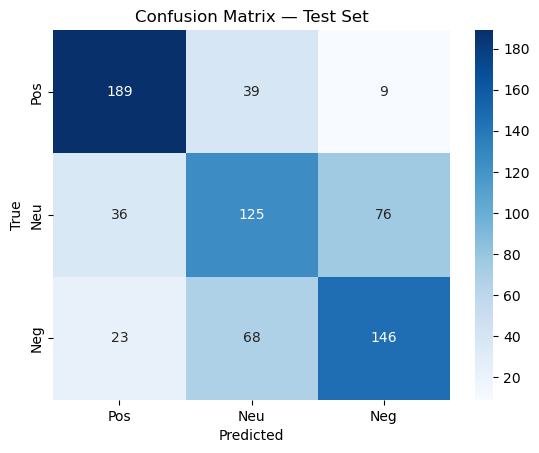

In [184]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = np.array([[189,39,9],
               [36,125,76],
               [23,68,146]])

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Pos","Neu","Neg"],
            yticklabels=["Pos","Neu","Neg"])
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix — Test Set")
plt.show()

In [185]:
best_pipe.predict(['This dress is wonderful!'])

array([1])

In [186]:
neutral_examples = [
    "The product is okay, nothing special about it.",
    "It fits fine but not exactly as shown in the picture.",
    "Material is average, color slightly different than expected.",
    "Delivery took the normal amount of time, overall decent.",
    "Neither good nor bad — it does the job."
]

In [187]:
best_pipe.predict(neutral_examples)

array([-1, -1,  0, -1, -1])

In [188]:
negative_examples = [
    "The quality is terrible, it ripped after one use.",
    "Very disappointed — the size is completely wrong.",
    "Cheap material and awful stitching, not worth the money.",
    "The item arrived damaged and customer service was unhelpful.",
    "Color faded after washing, definitely wouldn’t recommend."
]

In [189]:
best_pipe.predict(negative_examples)

array([-1, -1, -1, -1,  1])

In [190]:
positive_examples = [
    "I absolutely love this dress, it fits perfectly and the color is amazing!",
    "The fabric feels premium and very comfortable.",
    "Exceeded my expectations — great quality for the price.",
    "Fast delivery and the item looks exactly like the photos!",
    "I’m so happy with this purchase, will definitely buy again."
]

In [191]:
best_pipe.predict(positive_examples)

array([ 1,  1,  1, -1,  1])

In [192]:
import sys 
for p in sys.path:
    print(p)

/Users/mosabahmed/miniconda3/envs/wcr-nlp/lib/python311.zip
/Users/mosabahmed/miniconda3/envs/wcr-nlp/lib/python3.11
/Users/mosabahmed/miniconda3/envs/wcr-nlp/lib/python3.11/lib-dynload

/Users/mosabahmed/miniconda3/envs/wcr-nlp/lib/python3.11/site-packages
/Users/mosabahmed/Dev/AI_MENTORSHIP/HWs/Women Clothing
/Users/mosabahmed/Dev/AI_MENTORSHIP/HWs/Women Clothing


/Users/mosabahmed/Dev/AI_MENTORSHIP/HWs/Women Clothing/notebooks
